# Bayesian Logistic Regression with ESS and MESS

This notebook implements Bayesian logistic regression using Elliptical Slice Sampling (ESS) and MESS (Multiple-proposal ESS) from the original Murray et al. (2010) paper. We compare ESS, MESS uniform, and MESS with different distance metrics (angular, euclidean) on a synthetic binary classification problem.

Key metrics tracked:
- Number of shrinking steps (intervals)
- Effective Sample Size (ESS)
- Mean Squared Jumping Distance (MSJD)
- Computation time

## Import Required Libraries

In [16]:
import sys
import os
import time

# Get absolute path to src directory (go up from notebooks to repo root)
repo_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
src_path = os.path.join(repo_root, 'src')
sys.path.insert(0, src_path)

print(f"Repo root: {repo_root}")
print(f"Added to path: {src_path}")

import numpy as np
import matplotlib.pyplot as plt
from mess.algorithms.ess import ess_step
from mess.algorithms.mess import mess_step
from mess.algorithms.effective_sample_size import (
    estimate_effective_sample_size,
    compute_mean_squared_jumping_distance,
    compute_normalized_jumping_distance
)
from mess.problems.logistic_regression import BayesianLogisticRegression
from mess.data.logistic_regression import generate_logistic_regression_data

Repo root: /Users/guillers/Documents/GitHub/mess
Added to path: /Users/guillers/Documents/GitHub/mess/src


## Generate Synthetic Logistic Regression Data

In [17]:
# Generate synthetic logistic regression data
data = generate_logistic_regression_data(
    n_samples=100,
    n_features=10,
    seed=42
)

X = data['X']
y = data['y']
beta_true = data['beta_true']

# Create problem
problem = BayesianLogisticRegression(X, y, prior_var=1.0)

print(f"Data shapes:")
print(f"  X: {X.shape}")
print(f"  y: {y.shape}")
print(f"  Number of class 0: {np.sum(y == 0)}")
print(f"  Number of class 1: {np.sum(y == 1)}")
print(f"\nTrue coefficients: {beta_true}")

# Initialize sampling
beta0 = problem.sample_prior(np.random.default_rng(seed=42))
print(f"\nInitial log-likelihood: {problem.log_likelihood(beta0):.4f}")

Data shapes:
  X: (100, 10)
  y: (100,)
  Number of class 0: 52
  Number of class 1: 48

True coefficients: [-0.02964132 -0.36464347 -0.20723653  0.31695519  0.00149665  0.17010499
  0.33503962 -0.18742073  0.37812408  0.1894213 ]

Initial log-likelihood: -115.4835


## Experiment Setup

In [18]:
# Sampler parameters
n_iters = 1000
burn_in = 500
seed = 42

# MESS M values to test
M_values = [1, 2, 5, 10, 20, 50, 100]
M_values_filtered = [M for M in M_values if M <= 100]

print(f"Experiment setup:")
print(f"  n_iters: {n_iters}")
print(f"  burn_in: {burn_in}")
print(f"  M values: {M_values}")

Experiment setup:
  n_iters: 1000
  burn_in: 500
  M values: [1, 2, 5, 10, 20, 50, 100]


## Run MCMC Sampling Experiments

Run MESS with uniform, angular, and euclidean variants for different M values.

In [19]:
# Store results for all variants
results = {
    'uniform': {'intervals': {}, 'chains': {}, 'times': [], 'statistics': {}},
    'angular': {'intervals': {}, 'chains': {}, 'times': [], 'statistics': {}},
    'euclidean': {'intervals': {}, 'chains': {}, 'times': [], 'statistics': {}},
    'ess': {'uniform': {}, 'angular': {}, 'euclidean': {}},
    'msjd': {'uniform': {}, 'angular': {}, 'euclidean': {}},
    'log_likelihood': {'uniform': {}, 'angular': {}, 'euclidean': {}},
}

# Run MESS Uniform
print(f"Running MESS Uniform...")
for M in M_values:
    print(f"  M = {M}")
    rng = np.random.default_rng(seed)
    chain = np.zeros((n_iters, X.shape[1]))
    intervals = np.zeros(n_iters, dtype=int)
    x = beta0.copy()
    
    t0 = time.time()
    for t in range(n_iters):
        x, nr_intervals, _ = mess_step(x, problem, rng, M=M, use_lp=False)
        chain[t] = x
        intervals[t] = nr_intervals
    elapsed = time.time() - t0
    
    results['uniform']['chains'][M] = chain
    results['uniform']['intervals'][M] = intervals
    results['uniform']['times'].append(elapsed)
    
    # Compute statistics
    intervals_post = intervals[burn_in:]
    results['uniform']['statistics'][M] = {
        'mean_intervals': np.mean(intervals_post),
        'std_intervals': np.std(intervals_post),
        'median_intervals': np.median(intervals_post),
    }
    
    print(f"    Time: {elapsed:.2f}s, Mean intervals: {np.mean(intervals_post):.4f}")

# Run MESS Angular
print(f"\nRunning MESS Angular...")
for M in M_values_filtered:
    print(f"  M = {M}")
    rng = np.random.default_rng(seed)
    chain = np.zeros((n_iters + 1, X.shape[1]))
    chain[0] = beta0.copy()
    intervals = np.zeros(n_iters, dtype=int)
    x = beta0.copy()
    
    t0 = time.time()
    for t in range(n_iters):
        x, nr_intervals, _ = mess_step(x, problem, rng, M=M, use_lp=True,
                                       distance_metric='angular', lam=0.05)
        chain[t + 1] = x
        intervals[t] = nr_intervals
    elapsed = time.time() - t0
    
    results['angular']['chains'][M] = chain
    results['angular']['intervals'][M] = intervals
    results['angular']['times'].append(elapsed)
    
    # Compute statistics
    intervals_post = intervals[burn_in + 1:]
    results['angular']['statistics'][M] = {
        'mean_intervals': np.mean(intervals_post),
        'std_intervals': np.std(intervals_post),
        'median_intervals': np.median(intervals_post),
    }
    
    print(f"    Time: {elapsed:.2f}s, Mean intervals: {np.mean(intervals_post):.4f}")

# Run MESS Euclidean
print(f"\nRunning MESS Euclidean...")
for M in M_values_filtered:
    print(f"  M = {M}")
    rng = np.random.default_rng(seed)
    chain = np.zeros((n_iters + 1, X.shape[1]))
    chain[0] = beta0.copy()
    intervals = np.zeros(n_iters, dtype=int)
    x = beta0.copy()
    
    t0 = time.time()
    for t in range(n_iters):
        x, nr_intervals, _ = mess_step(x, problem, rng, M=M, use_lp=True,
                                       distance_metric='euclidean', lam=0.05)
        chain[t + 1] = x
        intervals[t] = nr_intervals
    elapsed = time.time() - t0
    
    results['euclidean']['chains'][M] = chain
    results['euclidean']['intervals'][M] = intervals
    results['euclidean']['times'].append(elapsed)
    
    # Compute statistics
    intervals_post = intervals[burn_in + 1:]
    results['euclidean']['statistics'][M] = {
        'mean_intervals': np.mean(intervals_post),
        'std_intervals': np.std(intervals_post),
        'median_intervals': np.median(intervals_post),
    }
    
    print(f"    Time: {elapsed:.2f}s, Mean intervals: {np.mean(intervals_post):.4f}")

print(f"\nAll experiments completed!")

Running MESS Uniform...
  M = 1
    Time: 0.13s, Mean intervals: 4.4480
  M = 2
    Time: 0.09s, Mean intervals: 2.5060
  M = 5
    Time: 0.10s, Mean intervals: 1.2920
  M = 10
    Time: 0.12s, Mean intervals: 0.7840
  M = 20
    Time: 0.18s, Mean intervals: 0.4140
  M = 50
    Time: 0.32s, Mean intervals: 0.1760
  M = 100
    Time: 0.55s, Mean intervals: 0.0380

Running MESS Angular...
  M = 1
    Time: 3.34s, Mean intervals: 4.7595
  M = 2
    Time: 3.19s, Mean intervals: 2.6232
  M = 5
    Time: 3.35s, Mean intervals: 1.2585
  M = 10
    Time: 3.48s, Mean intervals: 0.7735
  M = 20
    Time: 3.95s, Mean intervals: 0.4569
  M = 50
    Time: 6.13s, Mean intervals: 0.1623
  M = 100
    Time: 10.72s, Mean intervals: 0.0461

Running MESS Euclidean...
  M = 1
    Time: 3.41s, Mean intervals: 4.7595
  M = 2
    Time: 3.27s, Mean intervals: 2.6232
  M = 5
    Time: 3.33s, Mean intervals: 1.2285
  M = 10
    Time: 3.45s, Mean intervals: 0.6974
  M = 20
    Time: 3.98s, Mean intervals: 0.4569

## Compute ESS and MSJD

In [20]:
max_lag = 450

print(f"\nComputing ESS and MSJD")

# Compute ESS for Uniform
for M in M_values:
    chain = results['uniform']['chains'][M][burn_in:, :]
    ess_values = estimate_effective_sample_size(chain, max_lag=max_lag)
    msjd_values = compute_mean_squared_jumping_distance(chain)
    
    results['ess']['uniform'][M] = ess_values
    results['msjd']['uniform'][M] = msjd_values

# Compute ESS for Angular
for M in M_values_filtered:
    chain = results['angular']['chains'][M][burn_in+1:, :]
    ess_values = estimate_effective_sample_size(chain, max_lag=max_lag)
    msjd_values = compute_mean_squared_jumping_distance(chain)
    
    results['ess']['angular'][M] = ess_values
    results['msjd']['angular'][M] = msjd_values

# Compute ESS for Euclidean
for M in M_values_filtered:
    chain = results['euclidean']['chains'][M][burn_in+1:, :]
    ess_values = estimate_effective_sample_size(chain, max_lag=max_lag)
    msjd_values = compute_mean_squared_jumping_distance(chain)
    
    results['ess']['euclidean'][M] = ess_values
    results['msjd']['euclidean'][M] = msjd_values

# Compute log-likelihood for all chains
for M in M_values:
    # Uniform
    chain_uniform = results['uniform']['chains'][M]
    ll_uniform = np.array([problem.log_likelihood(chain_uniform[t, :]) for t in range(n_iters)])
    results['log_likelihood']['uniform'][M] = ll_uniform
    
    # Angular and Euclidean (only for M > 1)
    if M > 1 and M in M_values_filtered:
        chain_angular = results['angular']['chains'][M]
        ll_angular = np.array([problem.log_likelihood(chain_angular[t, :]) for t in range(n_iters + 1)])
        results['log_likelihood']['angular'][M] = ll_angular
        
        chain_euclidean = results['euclidean']['chains'][M]
        ll_euclidean = np.array([problem.log_likelihood(chain_euclidean[t, :]) for t in range(n_iters + 1)])
        results['log_likelihood']['euclidean'][M] = ll_euclidean

print("ESS, MSJD, and log-likelihood computation completed!")


Computing ESS and MSJD
Estimating ESS for each parameter.
Estimating ESS for each parameter.
Estimating ESS for each parameter.
Estimating ESS for each parameter.
Estimating ESS for each parameter.
Estimating ESS for each parameter.
Estimating ESS for each parameter.
Estimating ESS for each parameter.
Estimating ESS for each parameter.
Estimating ESS for each parameter.
Estimating ESS for each parameter.
Estimating ESS for each parameter.
Estimating ESS for each parameter.
Estimating ESS for each parameter.
Estimating ESS for each parameter.
Estimating ESS for each parameter.
Estimating ESS for each parameter.
Estimating ESS for each parameter.
Estimating ESS for each parameter.
Estimating ESS for each parameter.
Estimating ESS for each parameter.
ESS, MSJD, and log-likelihood computation completed!


## Figure 1: Effective Sample Size and MSJD Boxplots

Compare ESS and MSJD distributions across algorithms (Uniform, Angular, Euclidean) for different M values.

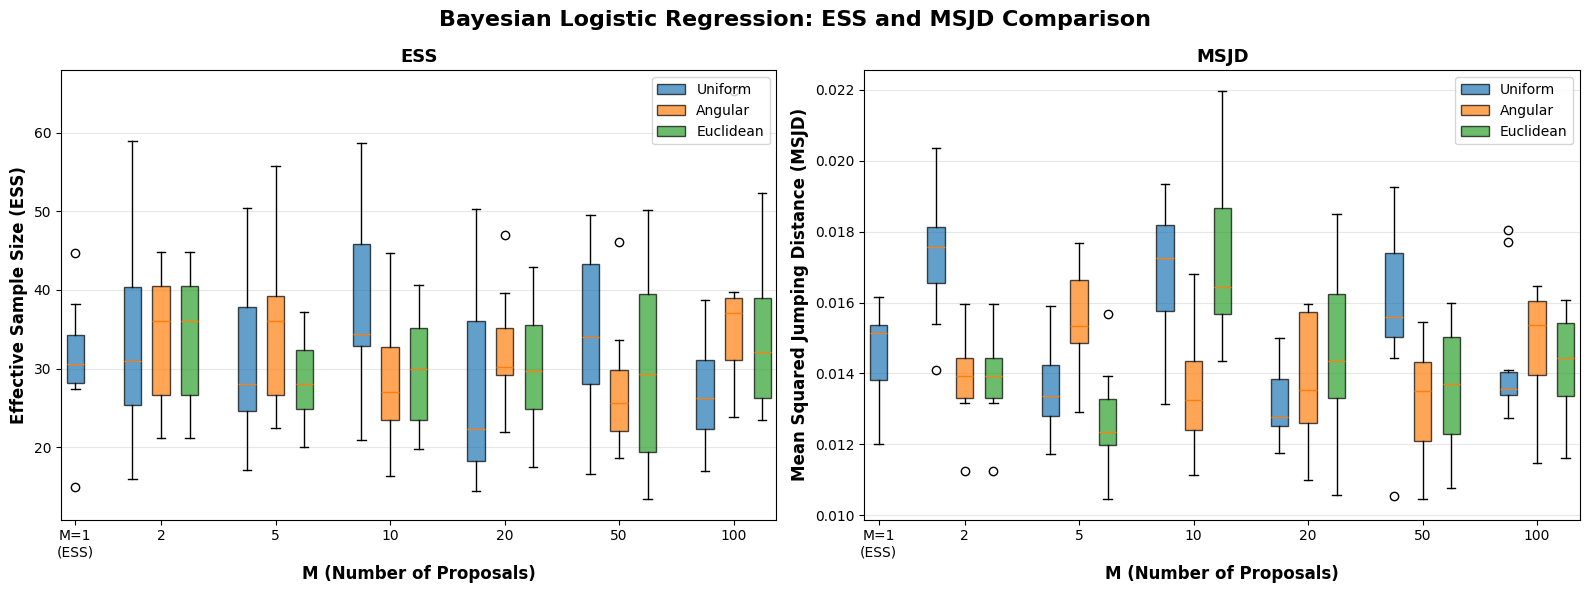

In [21]:
# Create 1x2 figure: ESS (left) and MSJD (right)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Bayesian Logistic Regression: ESS and MSJD Comparison', fontsize=16, fontweight='bold')

# Prepare boxplot data
uniform_ess_box = []
angular_ess_box = []
euclidean_ess_box = []
uniform_msjd_box = []
angular_msjd_box = []
euclidean_msjd_box = []
M_box = []

for M in M_values:
    uniform_ess_box.append(results['ess']['uniform'][M])
    uniform_msjd_box.append(results['msjd']['uniform'][M])
    M_box.append(M)
    
    if M > 1 and M in M_values_filtered:
        angular_ess_box.append(results['ess']['angular'][M])
        euclidean_ess_box.append(results['ess']['euclidean'][M])
        angular_msjd_box.append(results['msjd']['angular'][M])
        euclidean_msjd_box.append(results['msjd']['euclidean'][M])

# ===== ESS BOXPLOT (LEFT) =====
ax = axes[0]

# Positions
positions_uniform = []
positions_angular = []
positions_euclidean = []
pos_counter = 0

for i, M in enumerate(M_box):
    positions_uniform.append(pos_counter)
    pos_counter += 1
    
    if M > 1:
        positions_angular.append(pos_counter)
        pos_counter += 1
        positions_euclidean.append(pos_counter)
        pos_counter += 1
    
    pos_counter += 1

# Create boxplots
bp1 = ax.boxplot(uniform_ess_box, positions=positions_uniform, widths=0.6,
                  patch_artist=True, label='Uniform')
bp2 = ax.boxplot(angular_ess_box, positions=positions_angular, widths=0.6,
                  patch_artist=True, label='Angular')
bp3 = ax.boxplot(euclidean_ess_box, positions=positions_euclidean, widths=0.6,
                  patch_artist=True, label='Euclidean')

# Color boxes
for patch in bp1['boxes']:
    patch.set_facecolor('#1f77b4')
    patch.set_alpha(0.7)
for patch in bp2['boxes']:
    patch.set_facecolor('#ff7f0e')
    patch.set_alpha(0.7)
for patch in bp3['boxes']:
    patch.set_facecolor('#2ca02c')
    patch.set_alpha(0.7)

# X-axis labels
x_ticks = []
x_labels = []
for i, M in enumerate(M_box):
    if M == 1:
        x_ticks.append(positions_uniform[i])
        x_labels.append(f"M={int(M)}\n(ESS)")
    else:
        j = len([m for m in M_box[:i+1] if m > 1]) - 1
        avg_pos = (positions_uniform[i] + positions_angular[j] + positions_euclidean[j]) / 3
        x_ticks.append(avg_pos)
        x_labels.append(str(int(M)))

ax.set_xticks(x_ticks)
ax.set_xticklabels(x_labels)
ax.set_xlabel('M (Number of Proposals)', fontsize=12, fontweight='bold')
ax.set_ylabel('Effective Sample Size (ESS)', fontsize=12, fontweight='bold')
ax.set_title('ESS', fontsize=13, fontweight='bold')
ax.legend(fontsize=10, loc='best')
ax.grid(True, alpha=0.3, axis='y')

# ===== MSJD BOXPLOT (RIGHT) =====
ax = axes[1]

# Positions
positions_uniform_m = []
positions_angular_m = []
positions_euclidean_m = []
pos_counter = 0

for i, M in enumerate(M_box):
    positions_uniform_m.append(pos_counter)
    pos_counter += 1
    
    if M > 1:
        positions_angular_m.append(pos_counter)
        pos_counter += 1
        positions_euclidean_m.append(pos_counter)
        pos_counter += 1
    
    pos_counter += 1

# Create boxplots
bp1 = ax.boxplot(uniform_msjd_box, positions=positions_uniform_m, widths=0.6,
                  patch_artist=True, label='Uniform')
bp2 = ax.boxplot(angular_msjd_box, positions=positions_angular_m, widths=0.6,
                  patch_artist=True, label='Angular')
bp3 = ax.boxplot(euclidean_msjd_box, positions=positions_euclidean_m, widths=0.6,
                  patch_artist=True, label='Euclidean')

# Color boxes
for patch in bp1['boxes']:
    patch.set_facecolor('#1f77b4')
    patch.set_alpha(0.7)
for patch in bp2['boxes']:
    patch.set_facecolor('#ff7f0e')
    patch.set_alpha(0.7)
for patch in bp3['boxes']:
    patch.set_facecolor('#2ca02c')
    patch.set_alpha(0.7)

# X-axis labels
x_ticks = []
x_labels = []
for i, M in enumerate(M_box):
    if M == 1:
        x_ticks.append(positions_uniform_m[i])
        x_labels.append(f"M={int(M)}\n(ESS)")
    else:
        j = len([m for m in M_box[:i+1] if m > 1]) - 1
        avg_pos = (positions_uniform_m[i] + positions_angular_m[j] + positions_euclidean_m[j]) / 3
        x_ticks.append(avg_pos)
        x_labels.append(str(int(M)))

ax.set_xticks(x_ticks)
ax.set_xticklabels(x_labels)
ax.set_xlabel('M (Number of Proposals)', fontsize=12, fontweight='bold')
ax.set_ylabel('Mean Squared Jumping Distance (MSJD)', fontsize=12, fontweight='bold')
ax.set_title('MSJD', fontsize=13, fontweight='bold')
ax.legend(fontsize=10, loc='best')
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

In [22]:
# Save the last figure
fig.savefig('log_regression_ess_msjd_boxplots.png', dpi=600)


## Figure 2: Shrinking Steps and Computation Time

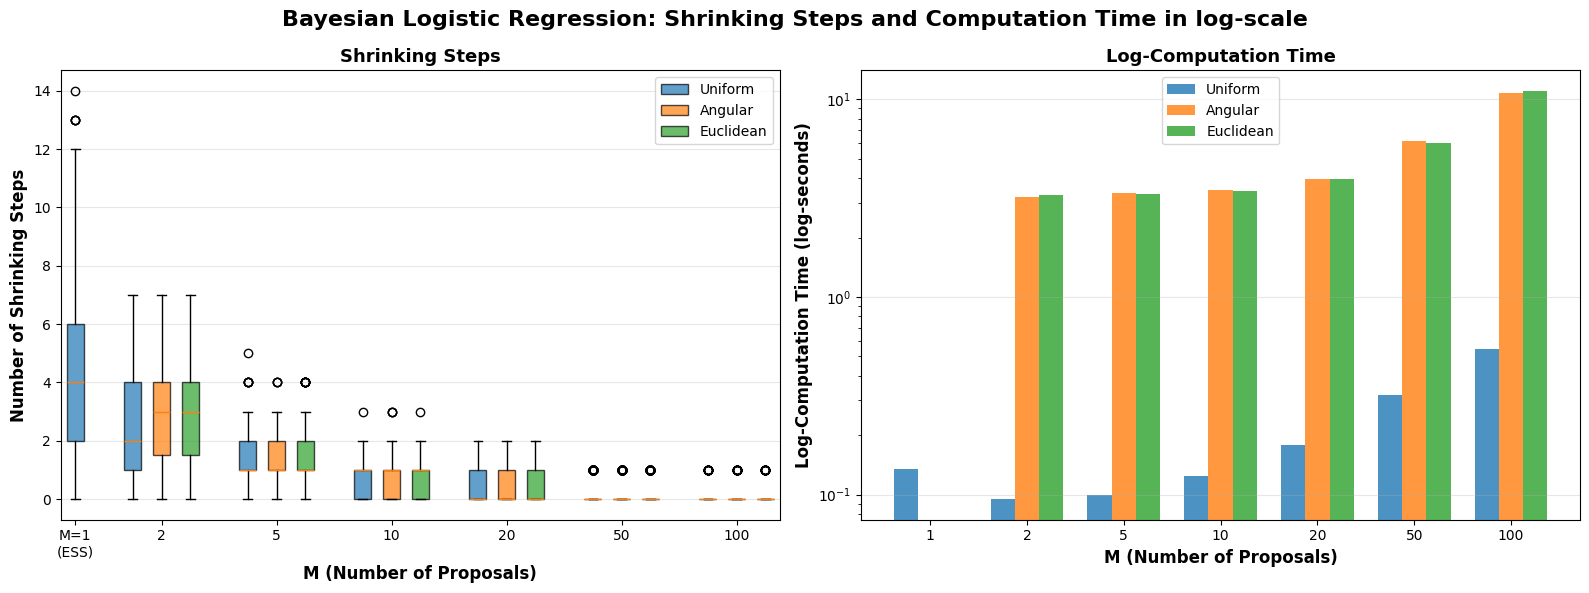

In [23]:
# Create 1x2 figure: Intervals and Time
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Bayesian Logistic Regression: Shrinking Steps and Computation Time in log-scale', fontsize=16, fontweight='bold')

use_log_scale = True  # Set to True for log scale computation time

# Prepare data
uniform_intervals_box = []
angular_intervals_box = []
euclidean_intervals_box = []
M_box = []

for M in M_values:
    intervals = results['uniform']['intervals'][M][burn_in:]
    uniform_intervals_box.append(intervals)
    M_box.append(M)
    
    if M > 1 and M in M_values_filtered:
        intervals_ang = results['angular']['intervals'][M][burn_in+1:]
        intervals_euc = results['euclidean']['intervals'][M][burn_in+1:]
        angular_intervals_box.append(intervals_ang)
        euclidean_intervals_box.append(intervals_euc)

# ===== SHRINKING STEPS BOXPLOT (LEFT) =====
ax = axes[0]

# Positions
positions_uniform = []
positions_angular = []
positions_euclidean = []
pos_counter = 0

for i, M in enumerate(M_box):
    positions_uniform.append(pos_counter)
    pos_counter += 1
    
    if M > 1:
        positions_angular.append(pos_counter)
        pos_counter += 1
        positions_euclidean.append(pos_counter)
        pos_counter += 1
    
    pos_counter += 1

# Create boxplots
bp1 = ax.boxplot(uniform_intervals_box, positions=positions_uniform, widths=0.6,
                  patch_artist=True, label='Uniform')
bp2 = ax.boxplot(angular_intervals_box, positions=positions_angular, widths=0.6,
                  patch_artist=True, label='Angular')
bp3 = ax.boxplot(euclidean_intervals_box, positions=positions_euclidean, widths=0.6,
                  patch_artist=True, label='Euclidean')

# Color boxes
for patch in bp1['boxes']:
    patch.set_facecolor('#1f77b4')
    patch.set_alpha(0.7)
for patch in bp2['boxes']:
    patch.set_facecolor('#ff7f0e')
    patch.set_alpha(0.7)
for patch in bp3['boxes']:
    patch.set_facecolor('#2ca02c')
    patch.set_alpha(0.7)

# X-axis labels
x_ticks = []
x_labels = []
for i, M in enumerate(M_box):
    if M == 1:
        x_ticks.append(positions_uniform[i])
        x_labels.append(f"M={int(M)}\n(ESS)")
    else:
        j = len([m for m in M_box[:i+1] if m > 1]) - 1
        avg_pos = (positions_uniform[i] + positions_angular[j] + positions_euclidean[j]) / 3
        x_ticks.append(avg_pos)
        x_labels.append(str(int(M)))

ax.set_xticks(x_ticks)
ax.set_xticklabels(x_labels)
ax.set_xlabel('M (Number of Proposals)', fontsize=12, fontweight='bold')
ax.set_ylabel('Number of Shrinking Steps', fontsize=12, fontweight='bold')
ax.set_title('Shrinking Steps', fontsize=13, fontweight='bold')
ax.legend(fontsize=10, loc='best')
ax.grid(True, alpha=0.3, axis='y')

# ===== COMPUTATION TIME (RIGHT) =====
ax = axes[1]

# Prepare time data
M_for_time = list(M_values)
uniform_times = results['uniform']['times']
angular_times = results['angular']['times']
euclidean_times = results['euclidean']['times']

# Bar plot positions
x_pos = np.arange(len(M_for_time))
width = 0.25

# Create bars
bars1 = ax.bar(x_pos - width, uniform_times, width, label='Uniform',
                color='#1f77b4', alpha=0.8)

# Only plot angular and euclidean for M > 1
angular_times_aligned = []
euclidean_times_aligned = []
for M in M_for_time:
    if M > 1:
        idx = M_values_filtered.index(M)
        angular_times_aligned.append(angular_times[idx])
        euclidean_times_aligned.append(euclidean_times[idx])
    else:
        angular_times_aligned.append(np.nan)
        euclidean_times_aligned.append(np.nan)

bars2 = ax.bar(x_pos, angular_times_aligned, width, label='Angular',
                color='#ff7f0e', alpha=0.8)
bars3 = ax.bar(x_pos + width, euclidean_times_aligned, width, label='Euclidean',
                color='#2ca02c', alpha=0.8)

ax.set_xticks(x_pos)
ax.set_xticklabels([str(int(M)) for M in M_for_time])
ax.set_xlabel('M (Number of Proposals)', fontsize=12, fontweight='bold')
ax.set_ylabel('Log-Computation Time (log-seconds)', fontsize=12, fontweight='bold')
ax.set_title('Log-Computation Time', fontsize=13, fontweight='bold')

# Apply log scale if requested
if use_log_scale:
    ax.set_yscale('log')

ax.legend(fontsize=10, loc='best')
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

In [24]:
# Save the last figure
fig.savefig('log_regression_shrinking_log_cpu_boxplots.png', dpi=600)

## Figure 3: Trace Plots for M=1 (ESS)

Visualize the chains for the ESS sampler to assess convergence.

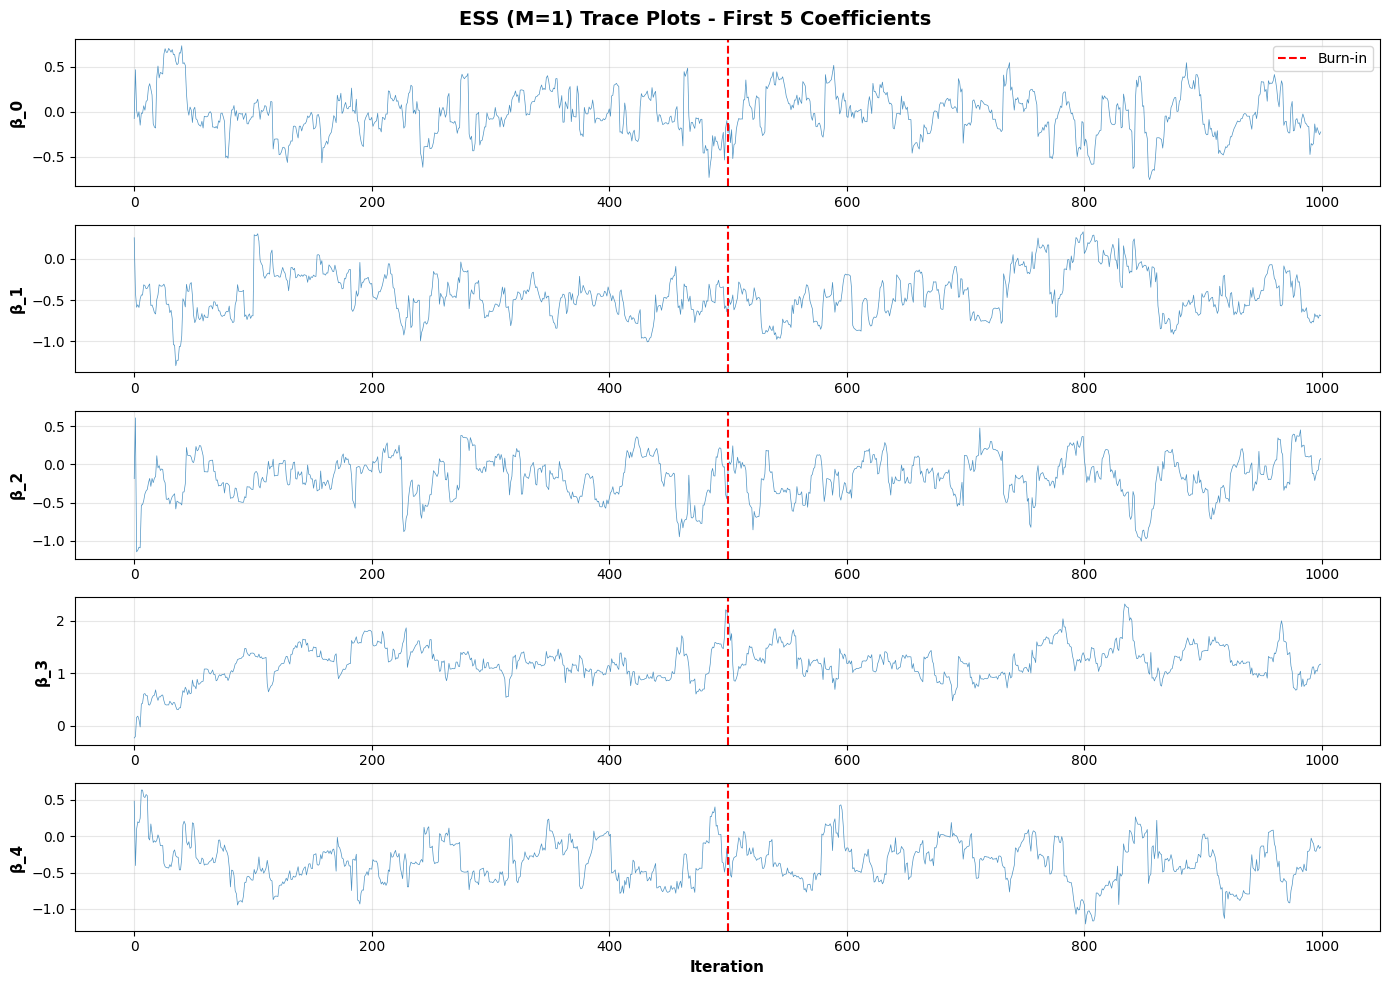

In [25]:
# Trace plots for first 5 features for M=1 (ESS)
chain_ess = results['uniform']['chains'][1]

fig, axes = plt.subplots(5, 1, figsize=(14, 10))
fig.suptitle('ESS (M=1) Trace Plots - First 5 Coefficients', fontsize=14, fontweight='bold')

for i in range(5):
    ax = axes[i]
    ax.plot(chain_ess[:, i], alpha=0.8, linewidth=0.5)
    ax.axvline(x=burn_in, color='red', linestyle='--', label=f'Burn-in')
    ax.set_ylabel(f'β_{i}', fontsize=11, fontweight='bold')
    ax.grid(True, alpha=0.3)
    if i == 0:
        ax.legend()

axes[-1].set_xlabel('Iteration', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

## Summary Statistics

In [26]:
# Print summary statistics
print("Summary Statistics")
print("=" * 80)

print("\nUNIFORM (Random transition matrix):")
for M in M_values:
    stats = results['uniform']['statistics'][M]
    print(f"  M = {M}:")
    print(f"    Mean intervals:   {stats['mean_intervals']:.4f} ± {stats['std_intervals']:.4f}")
    print(f"    Median intervals: {stats['median_intervals']:.4f}")

print("\nANGULAR (LP-based with angular distance):")
for M in M_values_filtered:
    if M > 1:
        stats = results['angular']['statistics'][M]
        print(f"  M = {M}:")
        print(f"    Mean intervals:   {stats['mean_intervals']:.4f} ± {stats['std_intervals']:.4f}")
        print(f"    Median intervals: {stats['median_intervals']:.4f}")

print("\nEUCLIDEAN (LP-based with euclidean distance):")
for M in M_values_filtered:
    if M > 1:
        stats = results['euclidean']['statistics'][M]
        print(f"  M = {M}:")
        print(f"    Mean intervals:   {stats['mean_intervals']:.4f} ± {stats['std_intervals']:.4f}")
        print(f"    Median intervals: {stats['median_intervals']:.4f}")

print("\n" + "=" * 80)
print("\nComputation Times:")
print(f"  Uniform:   {results['uniform']['times']}")
print(f"  Angular:   {results['angular']['times']}")
print(f"  Euclidean: {results['euclidean']['times']}")

Summary Statistics

UNIFORM (Random transition matrix):
  M = 1:
    Mean intervals:   4.4480 ± 2.8226
    Median intervals: 4.0000
  M = 2:
    Mean intervals:   2.5060 ± 1.5906
    Median intervals: 2.0000
  M = 5:
    Mean intervals:   1.2920 ± 0.9136
    Median intervals: 1.0000
  M = 10:
    Mean intervals:   0.7840 ± 0.6460
    Median intervals: 1.0000
  M = 20:
    Mean intervals:   0.4140 ± 0.5085
    Median intervals: 0.0000
  M = 50:
    Mean intervals:   0.1760 ± 0.3808
    Median intervals: 0.0000
  M = 100:
    Mean intervals:   0.0380 ± 0.1912
    Median intervals: 0.0000

ANGULAR (LP-based with angular distance):
  M = 2:
    Mean intervals:   2.6232 ± 1.5592
    Median intervals: 3.0000
  M = 5:
    Mean intervals:   1.2585 ± 0.8927
    Median intervals: 1.0000
  M = 10:
    Mean intervals:   0.7735 ± 0.6691
    Median intervals: 1.0000
  M = 20:
    Mean intervals:   0.4569 ± 0.5140
    Median intervals: 0.0000
  M = 50:
    Mean intervals:   0.1623 ± 0.3687
    Median

## Traceplots for Convergence Assessment

Visualize traceplots to assess when convergence is attained. Examine these plots and record the iteration number when convergence appears to be achieved for each method.


Traceplots for Bayesian Logistic Regression


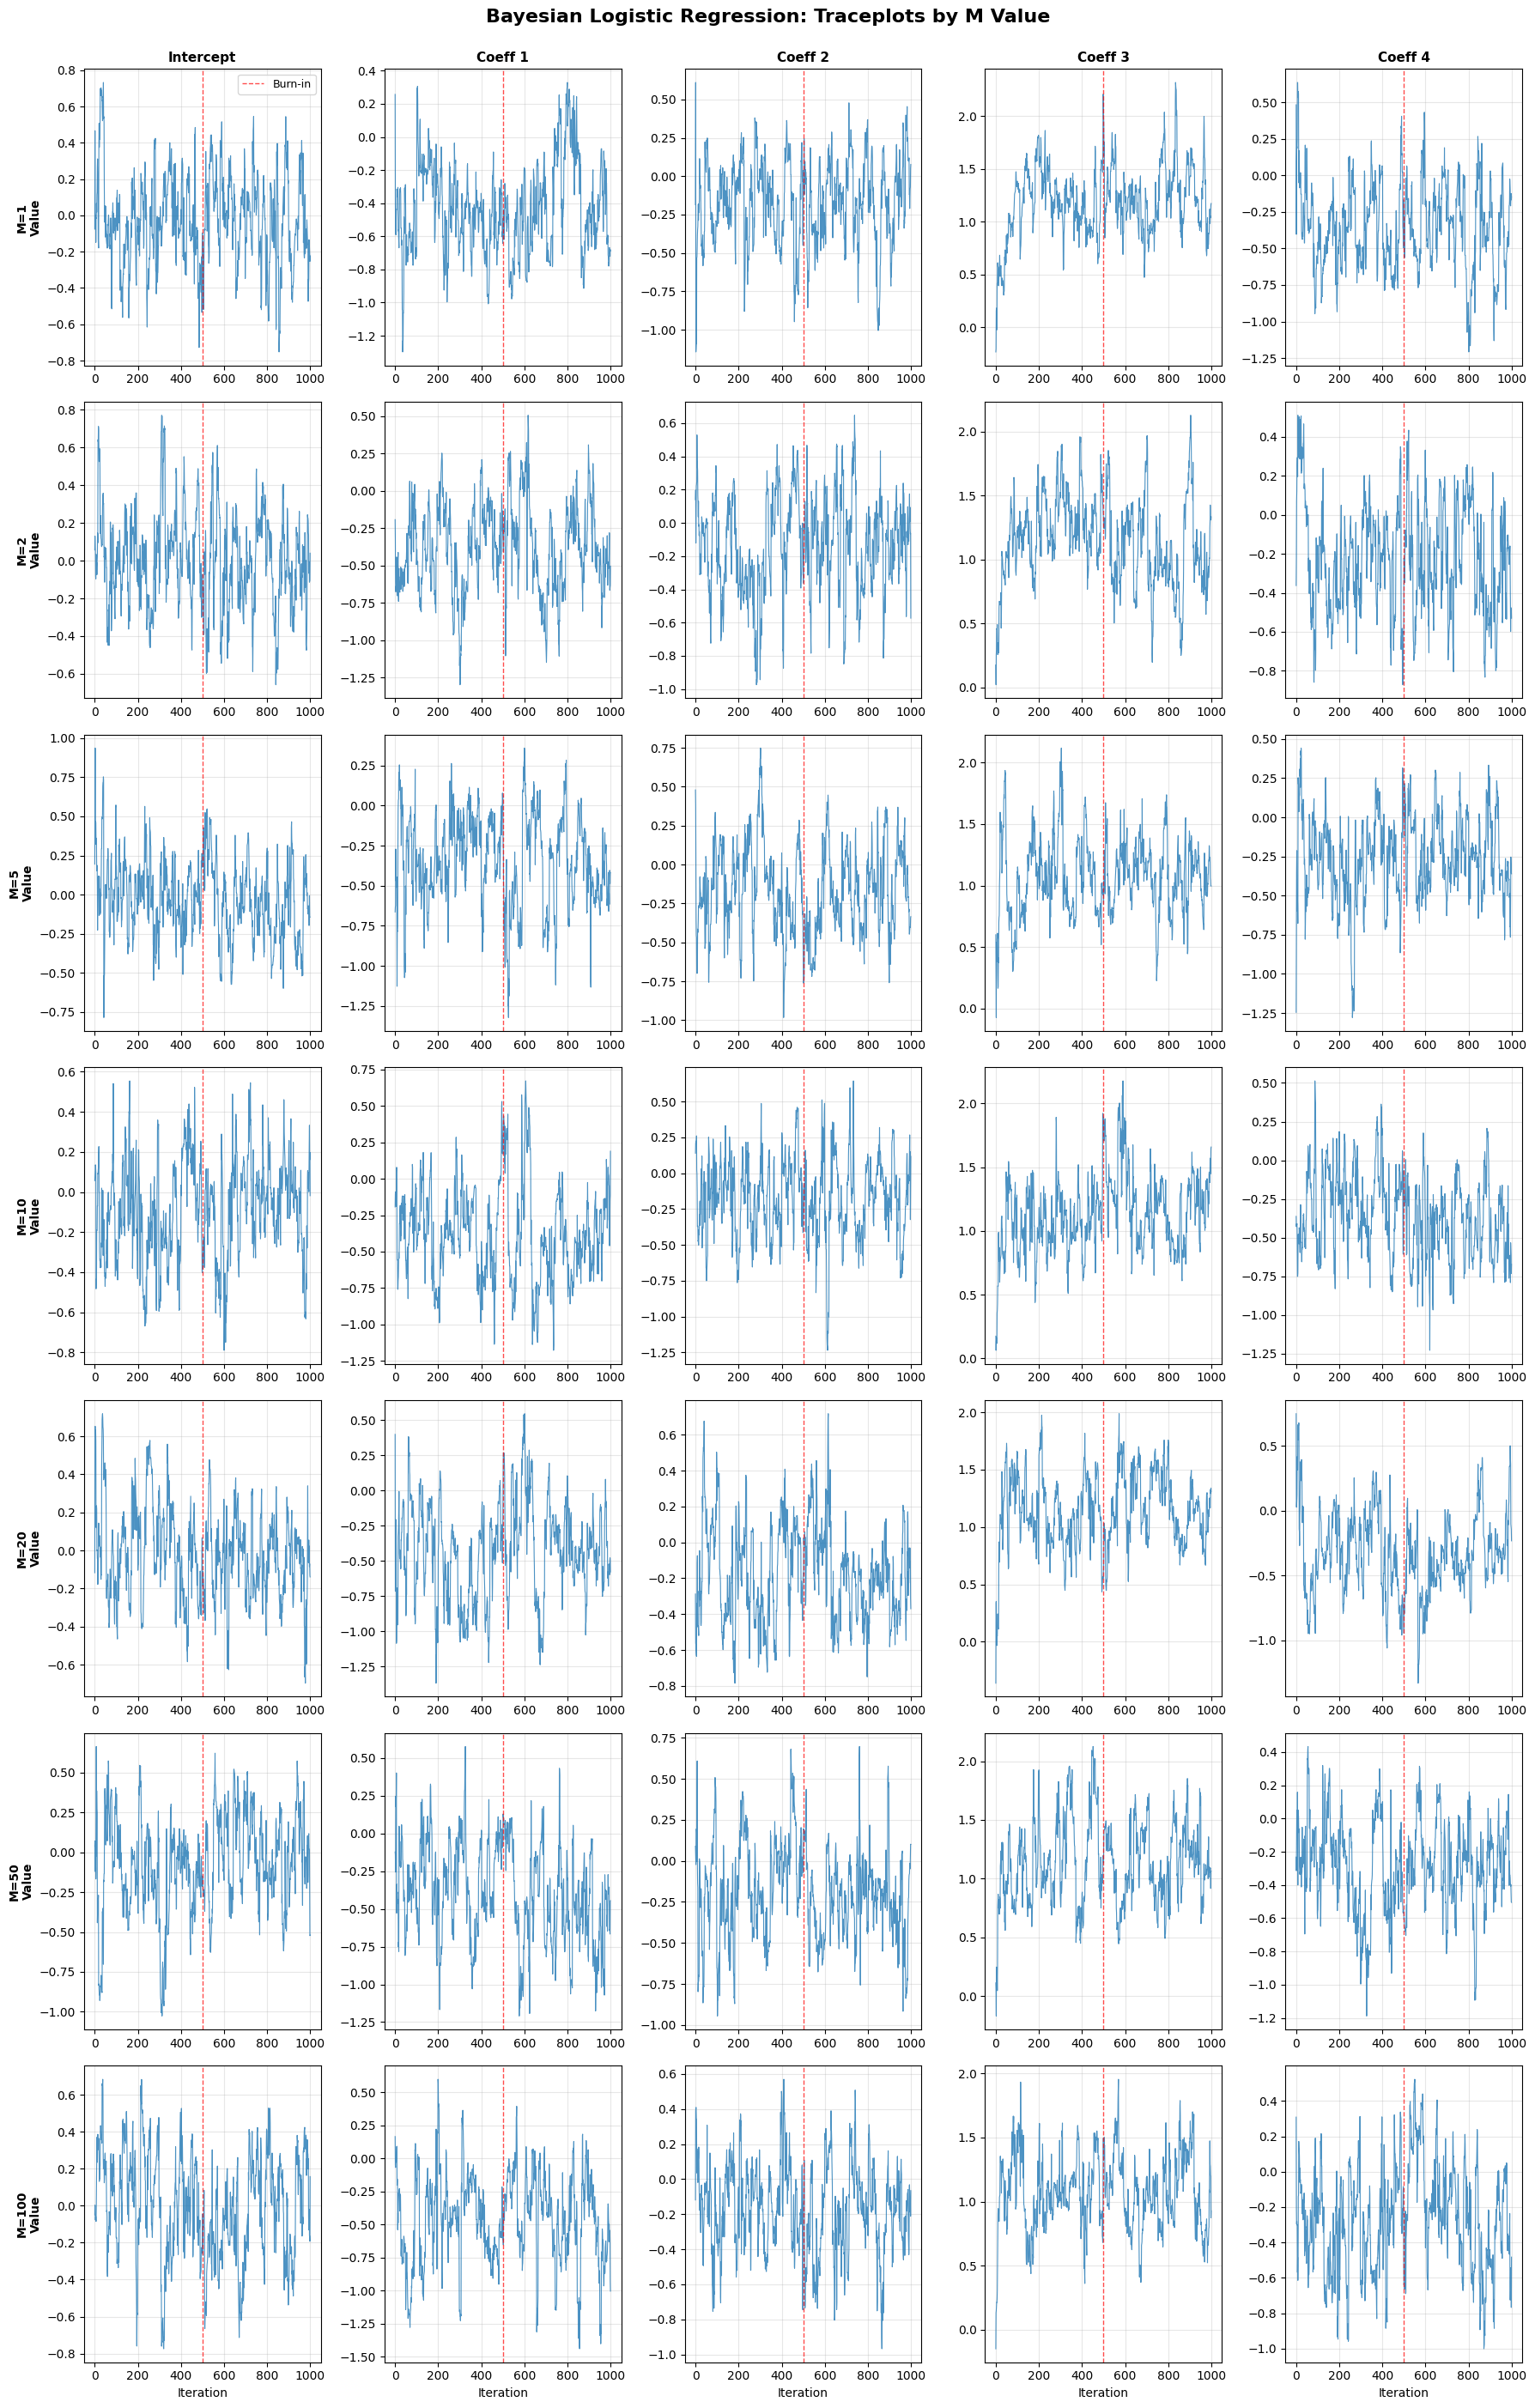

In [27]:
# Create traceplots for each method to assess convergence
# Select a subset of components to visualize (first 5 parameters or all if fewer)
num_components_to_plot = min(5, X.shape[1] + 1)  # +1 for the intercept

print(f"\n{'='*80}")
print(f"Traceplots for Bayesian Logistic Regression")
print(f"{'='*80}")

# Create figure with subplots for different M values
fig, axes = plt.subplots(len(M_values), num_components_to_plot, figsize=(18, 4*len(M_values)))
if len(M_values) == 1:
    axes = axes.reshape(1, -1)

fig.suptitle(f'Bayesian Logistic Regression: Traceplots by M Value', fontsize=16, fontweight='bold', y=1.00)

for m_idx, M in enumerate(M_values):
    chain = results['uniform']['chains'][M]
    
    for comp_idx in range(num_components_to_plot):
        ax = axes[m_idx, comp_idx]
        ax.plot(chain[:, comp_idx], linewidth=0.8, alpha=0.8)
        ax.axvline(burn_in, color='red', linestyle='--', linewidth=1, alpha=0.7, label='Burn-in')
        
        if m_idx == 0:
            if comp_idx == 0:
                ax.set_title(f'Intercept', fontsize=11, fontweight='bold')
            else:
                ax.set_title(f'Coeff {comp_idx}', fontsize=11, fontweight='bold')
        if comp_idx == 0:
            ax.set_ylabel(f'M={M}\nValue', fontsize=10, fontweight='bold')
        if m_idx == len(M_values) - 1:
            ax.set_xlabel('Iteration', fontsize=10)
        
        ax.grid(True, alpha=0.3)
        if m_idx == 0 and comp_idx == 0:
            ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

## Convergence Iteration Comparison

Record the iteration number at which convergence is attained for each method based on the traceplots above. Then visualize the comparison.

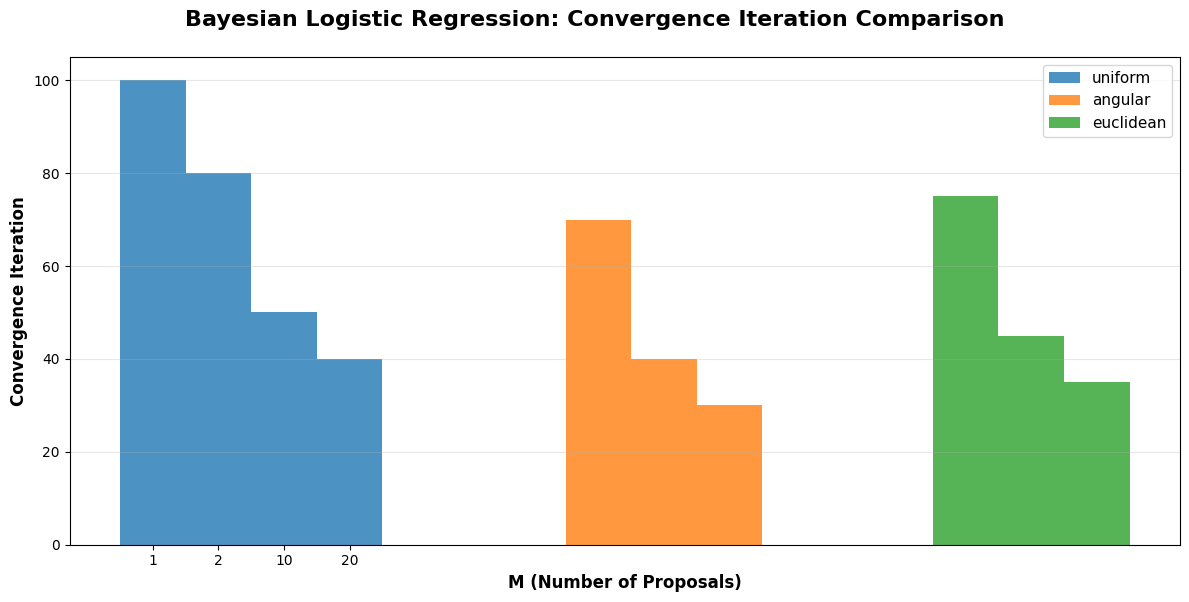

In [28]:
# Manually record convergence iterations for each method
# Edit the values below based on your visual inspection of the traceplots

convergence_iterations = {
    'uniform': {1: 100, 2: 80, 10: 50, 20: 40},
    'angular': {2: 70, 10: 40, 20: 30},
    'euclidean': {2: 75, 10: 45, 20: 35},
}

# Create comparison plot
fig, ax = plt.subplots(figsize=(12, 6))

fig.suptitle('Bayesian Logistic Regression: Convergence Iteration Comparison', 
             fontsize=16, fontweight='bold', y=0.995)

# Prepare data for plotting
x_pos = 0
x_labels = []
x_ticks = []

colors = {'uniform': '#1f77b4', 'angular': '#ff7f0e', 'euclidean': '#2ca02c'}

for method in ['uniform', 'angular', 'euclidean']:
    method_data = convergence_iterations[method]
    M_vals = sorted(method_data.keys())
    
    positions = [x_pos + i*0.25 for i in range(len(M_vals))]
    iterations = [method_data[M] for M in M_vals]
    
    ax.bar(positions, iterations, width=0.25, label=method, 
           color=colors[method], alpha=0.8)
    
    if method == 'uniform':
        for i, (pos, M) in enumerate(zip(positions, M_vals)):
            x_ticks.append(pos)
            x_labels.append(str(M))
    
    x_pos += len(M_vals) * 0.3 + 0.5

ax.set_xticks(x_ticks)
ax.set_xticklabels(x_labels)
ax.set_xlabel('M (Number of Proposals)', fontsize=12, fontweight='bold')
ax.set_ylabel('Convergence Iteration', fontsize=12, fontweight='bold')
ax.legend(fontsize=11, loc='best')
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

## Log-Likelihood Traceplots

Examine how the log-likelihood evolves across iterations for different methods to assess convergence behavior.

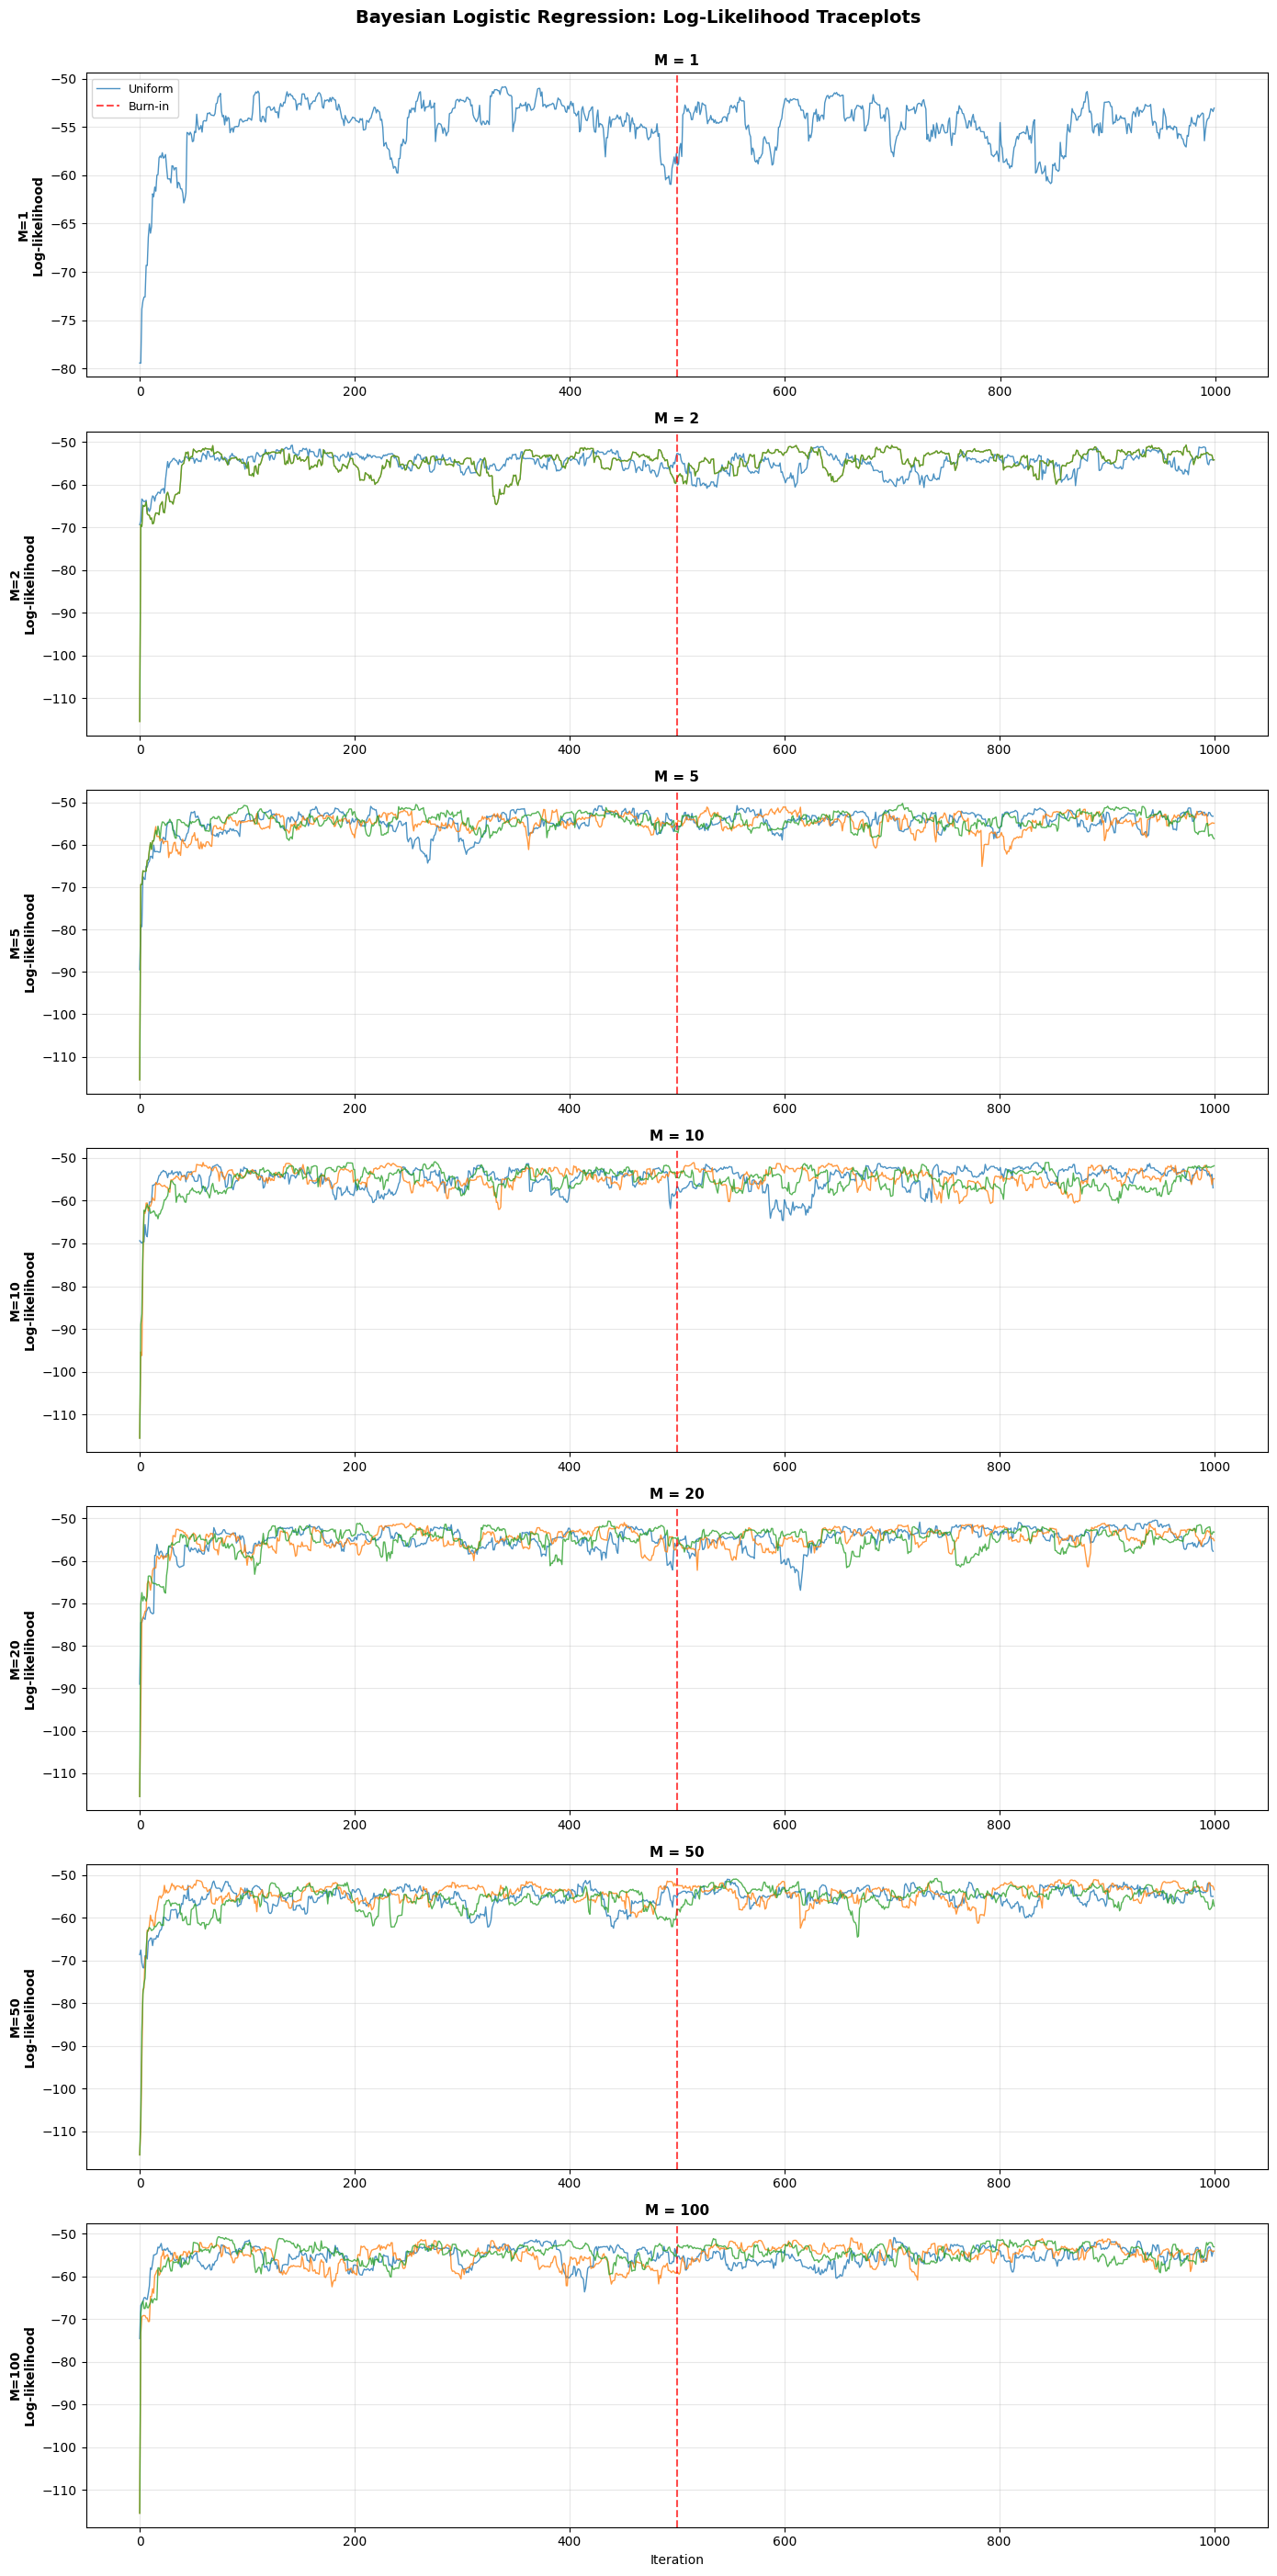

In [ ]:
# Create log-likelihood traceplots for each M value (plot only until burnin)
fig, axes = plt.subplots(len(M_values), 1, figsize=(14, 4*len(M_values)))
if len(M_values) == 1:
    axes = [axes]

fig.suptitle('Bayesian Logistic Regression: Log-Likelihood Traceplots (Until Burnin)', 
             fontsize=14, fontweight='bold', y=0.995)

for m_idx, M in enumerate(M_values):
    ax = axes[m_idx]
    
    # Plot log-likelihood for all three methods (up to burnin)
    ll_uniform = results['log_likelihood']['uniform'][M][:burn_in]
    ax.plot(ll_uniform, linewidth=1, alpha=0.8, label='Uniform', color='#1f77b4')
    
    if M > 1 and M in M_values_filtered:
        ll_angular = results['log_likelihood']['angular'][M][:burn_in]
        ll_euclidean = results['log_likelihood']['euclidean'][M][:burn_in]
        ax.plot(ll_angular, linewidth=1, alpha=0.8, label='Angular', color='#ff7f0e')
        ax.plot(ll_euclidean, linewidth=1, alpha=0.8, label='Euclidean', color='#2ca02c')
    
    ax.set_ylabel(f'M={M}\nLog-likelihood', fontsize=10, fontweight='bold')
    if m_idx == len(M_values) - 1:
        ax.set_xlabel('Iteration', fontsize=10)
    ax.set_title(f'M = {M}', fontsize=11, fontweight='bold')
    ax.grid(True, alpha=0.3)
    if m_idx == 0:
        ax.legend(fontsize=9, loc='best')

plt.tight_layout()
plt.show()

## Log-Likelihood ESS and MSJD Comparison

In [30]:
# Compute ESS and MSJD for log-likelihood
ll_ess = {'uniform': {}, 'angular': {}, 'euclidean': {}}
ll_msjd = {'uniform': {}, 'angular': {}, 'euclidean': {}}

# Uniform
for M in M_values:
    ll = results['log_likelihood']['uniform'][M][burn_in:]
    ll_ess['uniform'][M] = estimate_effective_sample_size(ll.reshape(-1, 1), max_lag=max_lag)[0]
    ll_msjd['uniform'][M] = compute_mean_squared_jumping_distance(ll.reshape(-1, 1))[0]

# Angular and Euclidean
for M in M_values_filtered:
    # Angular
    ll_ang = results['log_likelihood']['angular'][M][burn_in+1:]
    ll_ess['angular'][M] = estimate_effective_sample_size(ll_ang.reshape(-1, 1), max_lag=max_lag)[0]
    ll_msjd['angular'][M] = compute_mean_squared_jumping_distance(ll_ang.reshape(-1, 1))[0]
    
    # Euclidean
    ll_euc = results['log_likelihood']['euclidean'][M][burn_in+1:]
    ll_ess['euclidean'][M] = estimate_effective_sample_size(ll_euc.reshape(-1, 1), max_lag=max_lag)[0]
    ll_msjd['euclidean'][M] = compute_mean_squared_jumping_distance(ll_euc.reshape(-1, 1))[0]

# Create comparison plots
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

fig.suptitle('Bayesian Logistic Regression: Log-Likelihood ESS and MSJD', 
             fontsize=16, fontweight='bold', y=0.995)

# Prepare data
M_box = list(M_values)
uniform_ess_box = [ll_ess['uniform'][M] for M in M_values]
uniform_msjd_box = [ll_msjd['uniform'][M] for M in M_values]
angular_ess_box = [ll_ess['angular'][M] for M in M_values_filtered]
euclidean_ess_box = [ll_ess['euclidean'][M] for M in M_values_filtered]
angular_msjd_box = [ll_msjd['angular'][M] for M in M_values_filtered]
euclidean_msjd_box = [ll_msjd['euclidean'][M] for M in M_values_filtered]

# Positions
positions_uniform = []
positions_angular = []
positions_euclidean = []
pos_counter = 0

for i, M in enumerate(M_box):
    positions_uniform.append(pos_counter)
    pos_counter += 1
    
    if M > 1:
        positions_angular.append(pos_counter)
        pos_counter += 1
        positions_euclidean.append(pos_counter)
        pos_counter += 1
    
    pos_counter += 1

# ===== ESS PLOT (LEFT) =====
ax = axes[0]
ax.bar(positions_uniform, uniform_ess_box, width=0.25, label='Uniform',
       color='#1f77b4', alpha=0.8)
if angular_ess_box:
    ax.bar(positions_angular, angular_ess_box, width=0.25, label='Angular',
           color='#ff7f0e', alpha=0.8)
if euclidean_ess_box:
    ax.bar(positions_euclidean, euclidean_ess_box, width=0.25, label='Euclidean',
           color='#2ca02c', alpha=0.8)

x_ticks = []
x_labels = []
for i, M in enumerate(M_box):
    if M == 1:
        x_ticks.append(positions_uniform[i])
        x_labels.append(f"M={int(M)}")
    else:
        j = len([m for m in M_box[:i+1] if m > 1]) - 1
        avg_pos = (positions_uniform[i] + positions_angular[j] + positions_euclidean[j]) / 3
        x_ticks.append(avg_pos)
        x_labels.append(str(int(M)))

ax.set_xticks(x_ticks)
ax.set_xticklabels(x_labels)
ax.set_xlabel('M (Number of Proposals)', fontsize=12, fontweight='bold')
ax.set_ylabel('Log-Likelihood ESS', fontsize=12, fontweight='bold')
ax.set_title('ESS', fontsize=13, fontweight='bold')
ax.legend(fontsize=11, loc='best')
ax.grid(True, alpha=0.3, axis='y')

# ===== MSJD PLOT (RIGHT) =====
ax = axes[1]
ax.bar(positions_uniform, uniform_msjd_box, width=0.25, label='Uniform',
       color='#1f77b4', alpha=0.8)
if angular_msjd_box:
    ax.bar(positions_angular, angular_msjd_box, width=0.25, label='Angular',
           color='#ff7f0e', alpha=0.8)
if euclidean_msjd_box:
    ax.bar(positions_euclidean, euclidean_msjd_box, width=0.25, label='Euclidean',
           color='#2ca02c', alpha=0.8)

ax.set_xticks(x_ticks)
ax.set_xticklabels(x_labels)
ax.set_xlabel('M (Number of Proposals)', fontsize=12, fontweight='bold')
ax.set_ylabel('Log-Likelihood MSJD', fontsize=12, fontweight='bold')
ax.set_title('MSJD', fontsize=13, fontweight='bold')
ax.legend(fontsize=11, loc='best')
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

Estimating ESS for each parameter.
Estimating ESS for each parameter.
Estimating ESS for each parameter.
Estimating ESS for each parameter.
Estimating ESS for each parameter.
Estimating ESS for each parameter.
Estimating ESS for each parameter.


KeyError: 1